In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from tensorflow.keras.applications import DenseNet121, DenseNet169, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 15

# Paths (adjust to your dataset structure: data/train/<class>, data/val/<class>)
TRAIN_DIR = "/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset-v2/data/train"
VAL_DIR   = "/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset-v2/data/val"

CLASS_NAMES = ["NonDemented", "VeryMildDemented", "MildDemented", "ModerateDemented"]

In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 33984 images belonging to 4 classes.
Found 6400 images belonging to 4 classes.
Class indices: {'NonDemented': 0, 'VeryMildDemented': 1, 'MildDemented': 2, 'ModerateDemented': 3}


In [3]:
from tensorflow.keras import backend as K

def channel_attention(input_feature, ratio=8):
    channel = input_feature.shape[-1]

    shared_dense_one = layers.Dense(channel // ratio, activation="relu",
                                     kernel_initializer="he_normal", use_bias=True)
    shared_dense_two = layers.Dense(channel, kernel_initializer="he_normal", use_bias=True)

    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = layers.Reshape((1, 1, channel))(avg_pool)
    avg_pool = shared_dense_one(avg_pool)
    avg_pool = shared_dense_two(avg_pool)

    max_pool = layers.GlobalMaxPooling2D()(input_feature)
    max_pool = layers.Reshape((1, 1, channel))(max_pool)
    max_pool = shared_dense_one(max_pool)
    max_pool = shared_dense_two(max_pool)

    cbam_feature = layers.Add()([avg_pool, max_pool])
    cbam_feature = layers.Activation("sigmoid")(cbam_feature)

    return layers.Multiply()([input_feature, cbam_feature])


def spatial_attention(input_feature, kernel_size=7):
    avg_pool = layers.Lambda(lambda x: K.mean(x, axis=-1, keepdims=True))(input_feature)
    max_pool = layers.Lambda(lambda x: K.max(x, axis=-1, keepdims=True))(input_feature)
    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])

    cbam_feature = layers.Conv2D(filters=1, kernel_size=kernel_size, strides=1,
                                  padding="same", activation="sigmoid",
                                  kernel_initializer="he_normal", use_bias=False)(concat)

    return layers.Multiply()([input_feature, cbam_feature])


def cbam_block(input_feature, ratio=8, kernel_size=7):
    x = channel_attention(input_feature, ratio)
    x = spatial_attention(x, kernel_size)
    return x

In [4]:
def build_cbam_densenet121(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    base_model = DenseNet121(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = True

    # Freeze early layers, fine-tune deeper layers
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    x = base_model.output               # feature map from DenseNet121
    x = cbam_block(x, ratio=8, kernel_size=7)   # attention-guided block

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=outputs, name="CBAM_DenseNet121")
    return model


model = build_cbam_densenet121()
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

I0000 00:00:1784911478.009030      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784911478.011913      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "CBAM_DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,597,734 (28.98 MB)

 Trainable params: 1,201,126 (4.58 MB)

 Non-trainable params: 6,396,608 (24.40 MB)

In [5]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7),
    ModelCheckpoint("cbam_densenet121_best.keras", monitor="val_accuracy",
                    save_best_only=True, mode="max")
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/15
   1/1062 ━━━━━━━━━━━━━━━━━━━━ 11:40:40 40s/step - accuracy: 0.2188 - loss: 2.1871

I0000 00:00:1784911529.790303     145 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1062/1062 ━━━━━━━━━━━━━━━━━━━━ 641s 567ms/step - accuracy: 0.5389 - loss: 1.0498 - val_accuracy: 0.6406 - val_loss: 0.7682 - learning_rate: 1.0000e-04
Epoch 2/15
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 469s 441ms/step - accuracy: 0.7012 - loss: 0.6804 - val_accuracy: 0.7202 - val_loss: 0.6139 - learning_rate: 1.0000e-04
Epoch 3/15
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 482s 454ms/step - accuracy: 0.7778 - loss: 0.5270 - val_accuracy: 0.7670 - val_loss: 0.5085 - learning_rate: 1.0000e-04
Epoch 4/15
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 462s 434ms/step - accuracy: 0.8231 - loss: 0.4236 - val_accuracy: 0.8022 - val_loss: 0.4665 - learning_rate: 1.0000e-04
Epoch 5/15
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 466s 439ms/step - accuracy: 0.8525 - loss: 0.3582 - val_accuracy: 0.7678 - val_loss: 0.5660 - learning_rate: 1.0000e-04
Epoch 6/15
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 479s 451ms/step - accuracy: 0.8766 - loss: 0.3070 - val_accuracy: 0.8292 - val_loss: 0.4186 - learning_rate: 1.0000e-04
Epoch 7/15
1062/1062 ━━━━━━━━━━━━━━━━━━

200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step
Accuracy : 94.75%
Precision: 94.81%
Sensitivity (Recall): 94.75%
F1-score : 94.73%

Classification Report:
                   precision    recall  f1-score   support

     NonDemented       0.95      0.97      0.96      3200
VeryMildDemented       0.93      0.93      0.93      2240
    MildDemented       0.99      0.89      0.94       896
ModerateDemented       1.00      1.00      1.00        64

        accuracy                           0.95      6400
       macro avg       0.97      0.95      0.96      6400
    weighted avg       0.95      0.95      0.95      6400



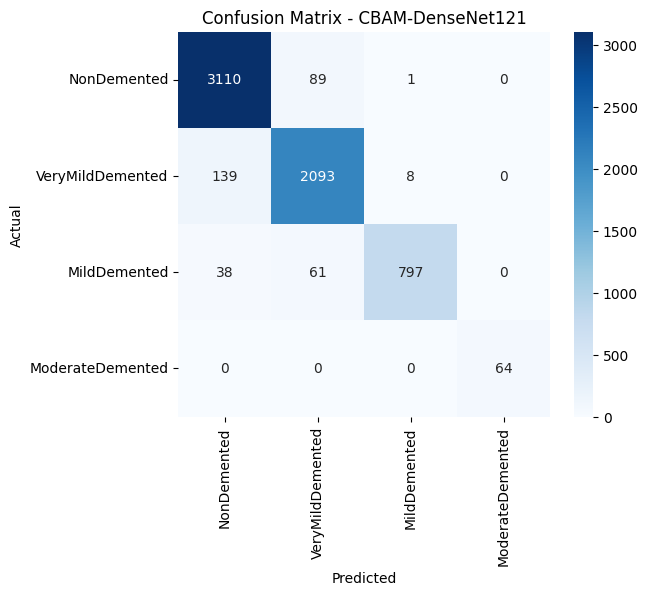

In [6]:
val_generator.reset()
y_pred_probs = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted")
rec  = recall_score(y_true, y_pred, average="weighted")
f1   = f1_score(y_true, y_pred, average="weighted")

print(f"Accuracy : {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Sensitivity (Recall): {rec*100:.2f}%")
print(f"F1-score : {f1*100:.2f}%")

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix - CBAM-DenseNet121")
plt.show()

200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 72ms/step
  OVERALL METRICS - CBAM-DenseNet121
Accuracy             : 94.75%
Precision (weighted) : 94.81%
Recall/Sensitivity   : 94.75%
F1-score (weighted)  : 94.73%

  PER-CLASS METRICS
NonDemented          | Precision:  94.62%  Recall:  97.19%  F1:  95.88%  (n=3200)
VeryMildDemented     | Precision:  93.31%  Recall:  93.44%  F1:  93.37%  (n=2240)
MildDemented         | Precision:  98.88%  Recall:  88.95%  F1:  93.65%  (n=896)
ModerateDemented     | Precision: 100.00%  Recall: 100.00%  F1: 100.00%  (n=64)

Full Classification Report:

                  precision    recall  f1-score   support

     NonDemented       0.95      0.97      0.96      3200
VeryMildDemented       0.93      0.93      0.93      2240
    MildDemented       0.99      0.89      0.94       896
ModerateDemented       1.00      1.00      1.00        64

        accuracy                           0.95      6400
       macro avg       0.97      0.95      0.96      6400
    weighted avg

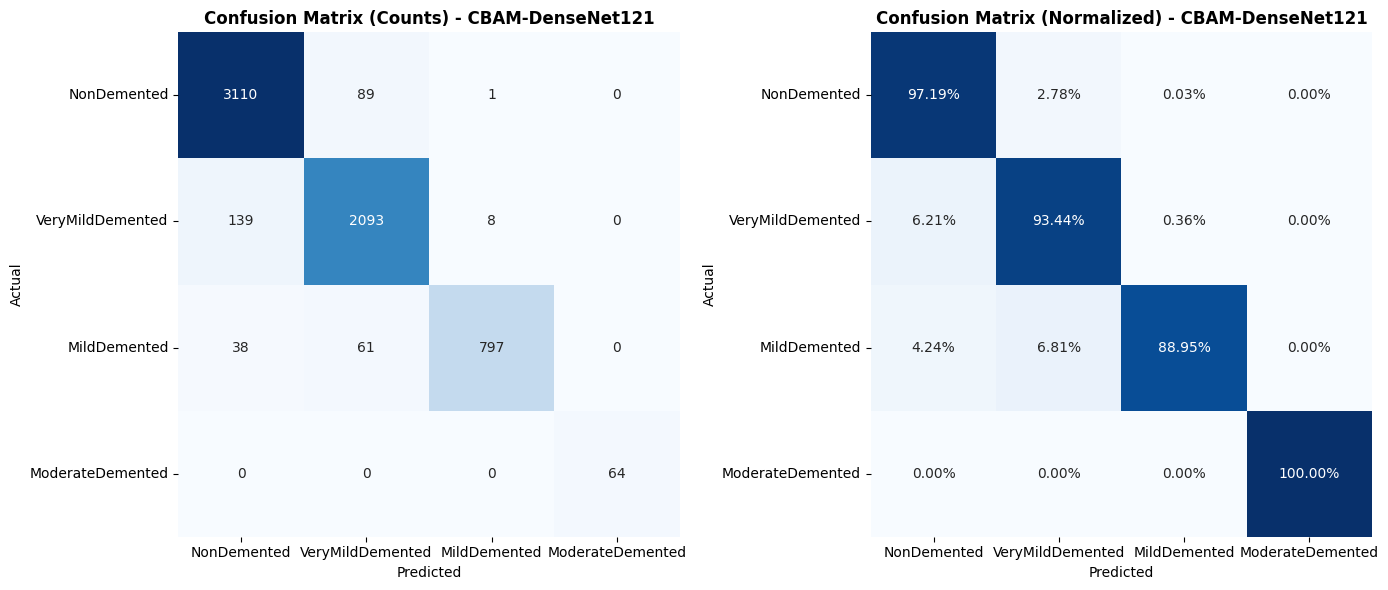

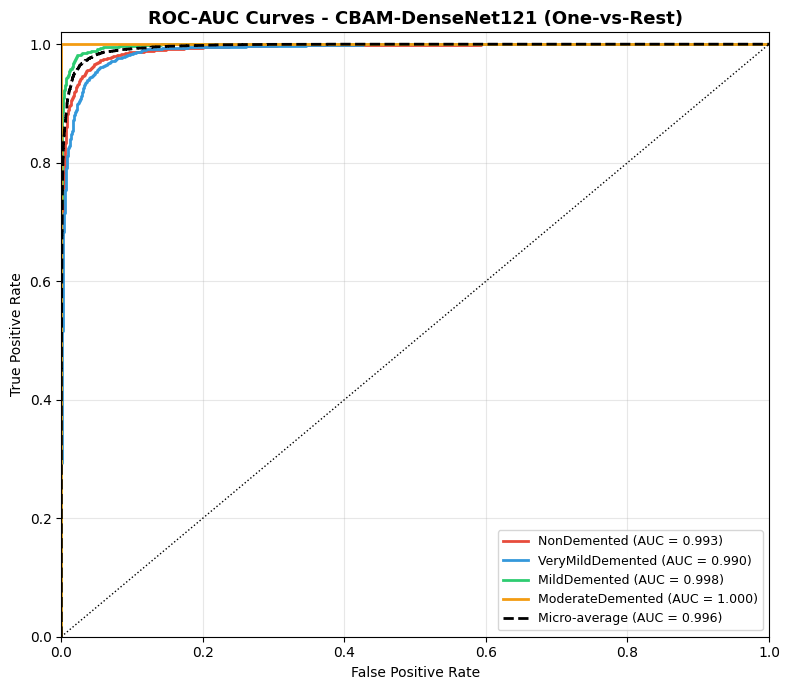


AUC per class:
  NonDemented         : 0.9925
  VeryMildDemented    : 0.9903
  MildDemented        : 0.9979
  ModerateDemented    : 1.0000
  Micro-average       : 0.9956


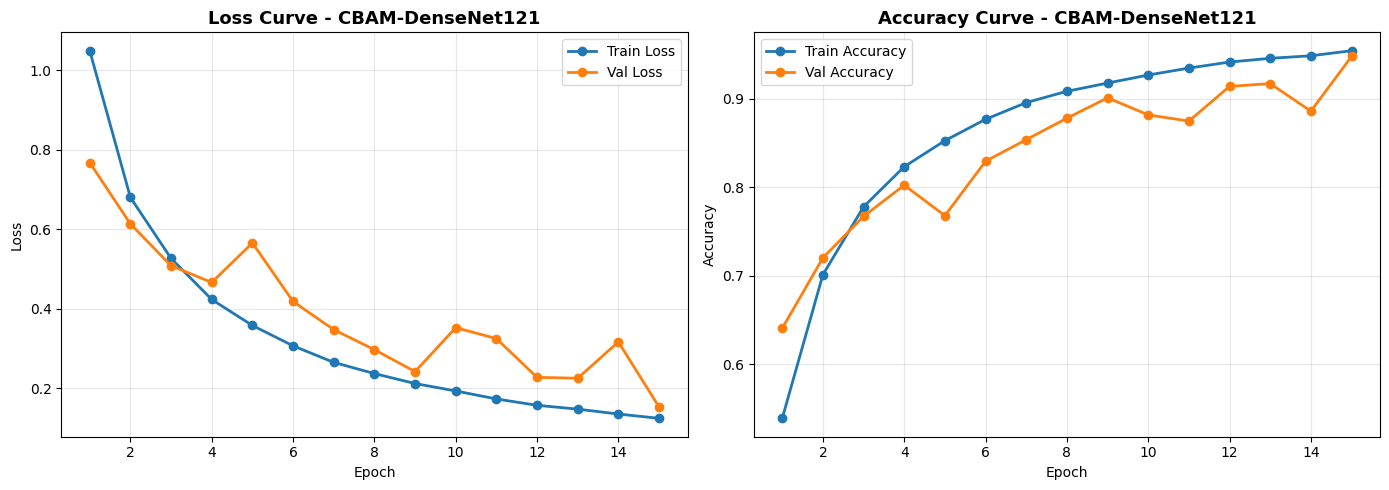

In [9]:
# ============================================================
# FULL EVALUATION SUITE - CBAM-DenseNet121
# ============================================================
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score, roc_curve, auc,
                              precision_recall_fscore_support)
from sklearn.preprocessing import label_binarize
from itertools import cycle

MODEL_NAME = "CBAM-DenseNet121"

# ------------------------------------------------------------
# 1. Predictions
# ------------------------------------------------------------
val_generator.reset()
y_pred_probs = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes
n_classes = len(CLASS_NAMES)

# ------------------------------------------------------------
# 2. Overall Metrics
# ------------------------------------------------------------
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted")
rec  = recall_score(y_true, y_pred, average="weighted")
f1   = f1_score(y_true, y_pred, average="weighted")

print("=" * 55)
print(f"  OVERALL METRICS - {MODEL_NAME}")
print("=" * 55)
print(f"Accuracy             : {acc*100:.2f}%")
print(f"Precision (weighted) : {prec*100:.2f}%")
print(f"Recall/Sensitivity   : {rec*100:.2f}%")
print(f"F1-score (weighted)  : {f1*100:.2f}%")

# ------------------------------------------------------------
# 3. Per-Class Metrics
# ------------------------------------------------------------
p_c, r_c, f1_c, support_c = precision_recall_fscore_support(y_true, y_pred)
print("\n" + "=" * 55)
print("  PER-CLASS METRICS")
print("=" * 55)
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:20s} | Precision: {p_c[i]*100:6.2f}%  "
          f"Recall: {r_c[i]*100:6.2f}%  F1: {f1_c[i]*100:6.2f}%  (n={support_c[i]})")

print("\nFull Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ------------------------------------------------------------
# 4. Confusion Matrix (counts + normalized)
# ------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0], cbar=False)
axes[0].set_title(f"Confusion Matrix (Counts) - {MODEL_NAME}", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1], cbar=False)
axes[1].set_title(f"Confusion Matrix (Normalized) - {MODEL_NAME}", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("cbam_densenet121_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 5. ROC-AUC Curves (One-vs-Rest, multiclass)
# ------------------------------------------------------------
y_true_bin = label_binarize(y_true, classes=range(n_classes))
fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_pred_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(8, 7))
colors = cycle(["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, linewidth=2,
             label=f"{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.3f})")

plt.plot(fpr["micro"], tpr["micro"], linestyle="--", color="black", linewidth=2,
          label=f"Micro-average (AUC = {roc_auc['micro']:.3f})")
plt.plot([0, 1], [0, 1], "k:", linewidth=1)

plt.xlim([0, 1]); plt.ylim([0, 1.02])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"ROC-AUC Curves - {MODEL_NAME} (One-vs-Rest)", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("cbam_densenet121_roc_auc.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nAUC per class:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:20s}: {roc_auc[i]:.4f}")
print(f"  {'Micro-average':20s}: {roc_auc['micro']:.4f}")

# ------------------------------------------------------------
# 6. Training Curves (Loss + Accuracy)
# ------------------------------------------------------------
hist = history.history
epochs_range = range(1, len(hist["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_range, hist["loss"], label="Train Loss", marker="o", linewidth=2)
axes[0].plot(epochs_range, hist["val_loss"], label="Val Loss", marker="o", linewidth=2)
axes[0].set_title(f"Loss Curve - {MODEL_NAME}", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, hist["accuracy"], label="Train Accuracy", marker="o", linewidth=2)
axes[1].plot(epochs_range, hist["val_accuracy"], label="Val Accuracy", marker="o", linewidth=2)
axes[1].set_title(f"Accuracy Curve - {MODEL_NAME}", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cbam_densenet121_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()

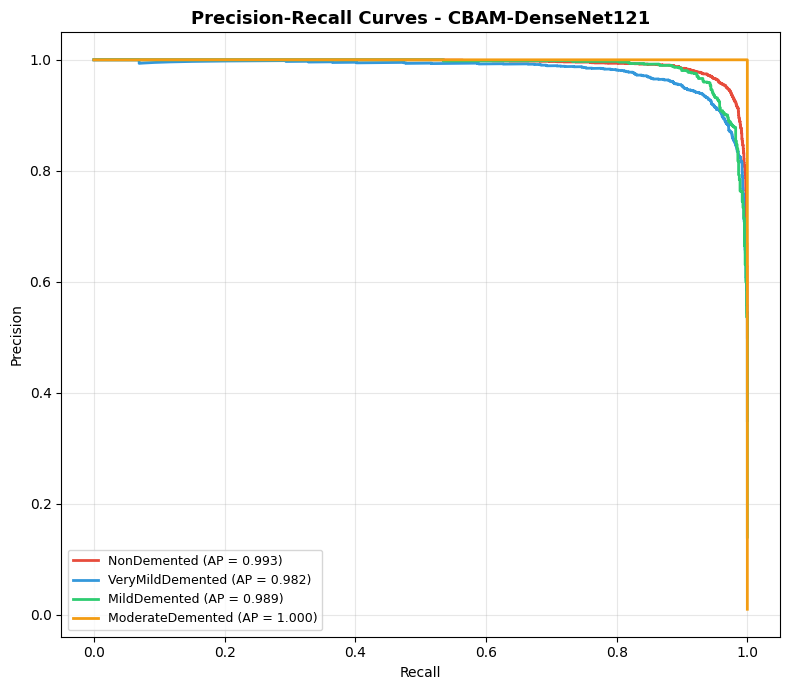

In [10]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

def plot_precision_recall_curves(y_true, y_pred_probs, class_names, model_name="CBAM-DenseNet121"):
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))

    plt.figure(figsize=(8, 7))
    colors = cycle(["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"])

    for i, color in zip(range(n_classes), colors):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred_probs[:, i])
        ap = average_precision_score(y_true_bin[:, i], y_pred_probs[:, i])
        plt.plot(recall, precision, color=color, linewidth=2,
                  label=f"{class_names[i]} (AP = {ap:.3f})")

    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curves - {model_name}", fontsize=13, fontweight="bold")
    plt.legend(loc="lower left", fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("cbam_densenet121_pr_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_precision_recall_curves(y_true, y_pred_probs, CLASS_NAMES)

#rk lime

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

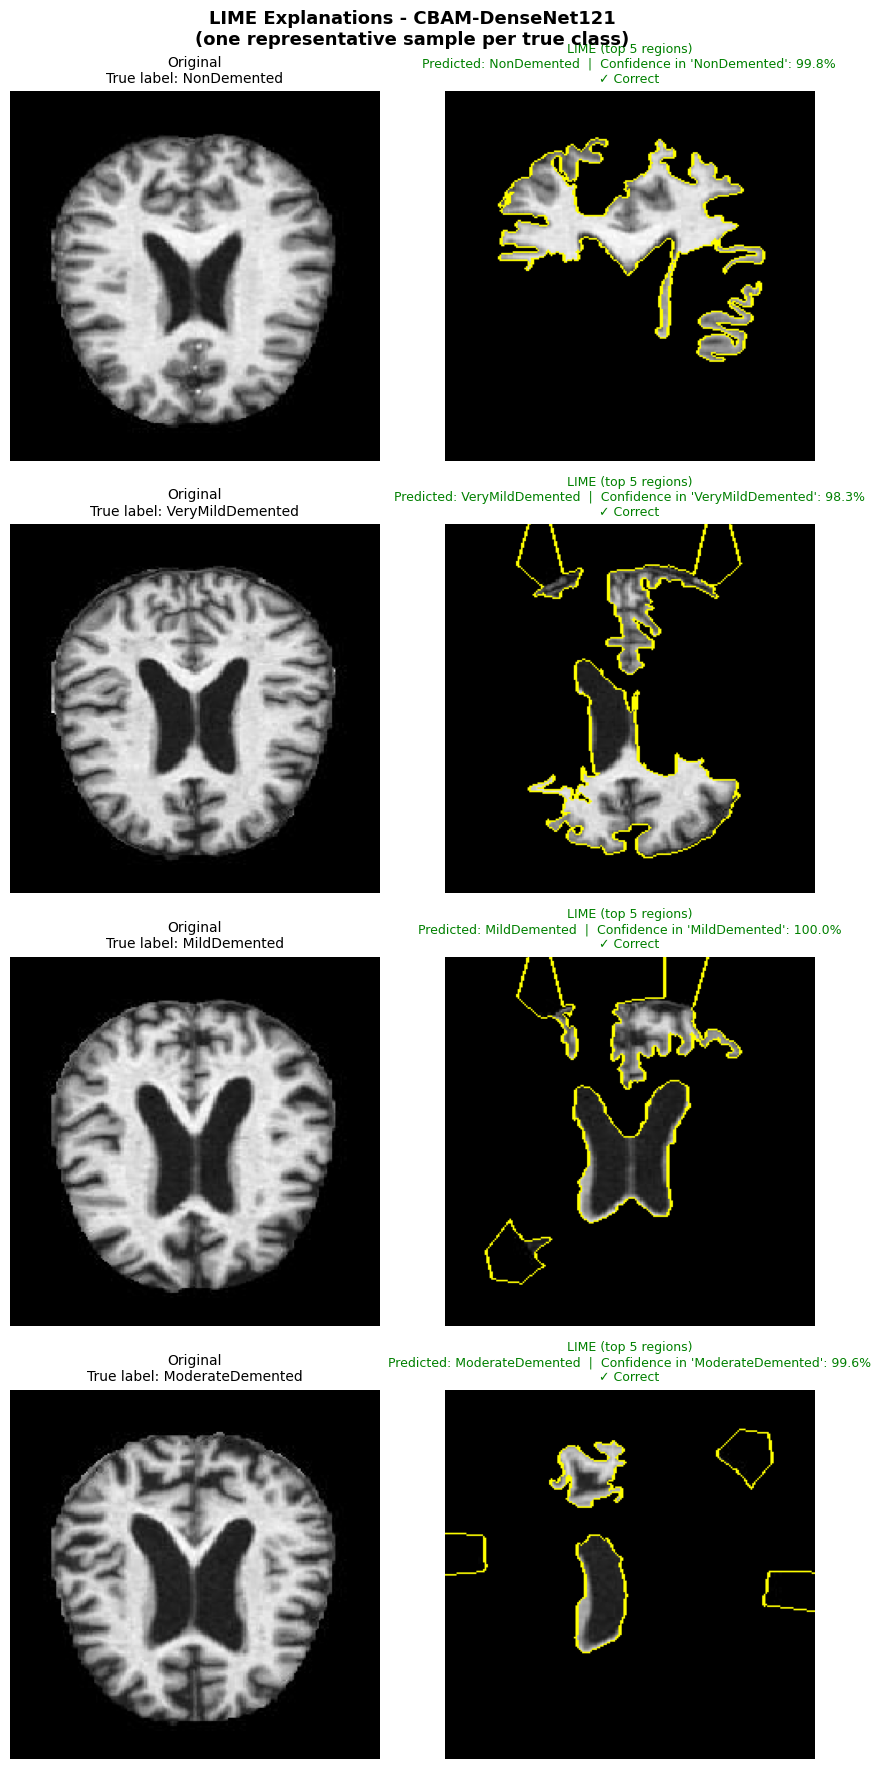

In [15]:
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
import matplotlib.pyplot as plt

# --- 1. Segmentation tuned for grayscale MRI ---
def mri_segmentation_fn(image):
    return slic(image, n_segments=100, compactness=5, sigma=1, start_label=1)

# --- 2. LIME explanation wrapper ---
def explain_with_lime(model, image, class_names, top_labels=4, num_samples=1500):
    explainer = lime_image.LimeImageExplainer()

    def predict_fn(images):
        return model.predict(images, verbose=0)

    explanation = explainer.explain_instance(
        image.astype("double"), predict_fn,
        top_labels=top_labels, hide_color=0, num_samples=num_samples,
        segmentation_fn=mri_segmentation_fn
    )
    return explanation

# --- 3. Grab one sample per class ---
def get_one_sample_per_class(val_generator, class_names):
    val_generator.reset()
    found = {}
    n_classes = len(class_names)

    for images, labels in val_generator:
        for img, lbl in zip(images, labels):
            true_idx = np.argmax(lbl)
            if true_idx not in found:
                found[true_idx] = img
        if len(found) == n_classes:
            break
        if val_generator.batch_index == 0:
            break

    return found

# --- 4. Main plotting function ---
def plot_lime_per_class(model, val_generator, class_names, num_features=5, num_samples=1500):
    gen_class_order = [None] * len(class_names)
    for name, idx in val_generator.class_indices.items():
        gen_class_order[idx] = name
    assert gen_class_order == class_names, (
        f"MISMATCH: val_generator order is {gen_class_order} but CLASS_NAMES is {class_names}. "
        f"Fix CLASS_NAMES to match before trusting any labels below."
    )

    samples = get_one_sample_per_class(val_generator, class_names)
    n = len(samples)

    fig, axes = plt.subplots(n, 2, figsize=(9, 4.5 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for row, (true_idx, img) in enumerate(sorted(samples.items())):
        pred_probs = model.predict(np.expand_dims(img, 0), verbose=0)[0]
        pred_idx = np.argmax(pred_probs)
        pred_conf = pred_probs[pred_idx] * 100

        true_name = class_names[true_idx]
        pred_name = class_names[pred_idx]
        correct = (true_idx == pred_idx)

        explanation = explain_with_lime(model, img, class_names, num_samples=num_samples)
        temp, mask = explanation.get_image_and_mask(
            pred_idx, positive_only=True, num_features=num_features, hide_rest=True
        )

        axes[row, 0].imshow(img)
        axes[row, 0].set_title(f"Original\nTrue label: {true_name}", fontsize=10)
        axes[row, 0].axis("off")

        status = "✓ Correct" if correct else "✗ Misclassified"
        title_color = "green" if correct else "red"
        axes[row, 1].imshow(mark_boundaries(temp, mask))
        axes[row, 1].set_title(
            f"LIME (top {num_features} regions)\n"
            f"Predicted: {pred_name}  |  Confidence in '{pred_name}': {pred_conf:.1f}%\n"
            f"{status}",
            fontsize=9, color=title_color
        )
        axes[row, 1].axis("off")

    fig.suptitle("LIME Explanations - CBAM-DenseNet121\n(one representative sample per true class)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("lime_per_class.png", dpi=300, bbox_inches="tight")
    plt.show()

# --- Run it ---
plot_lime_per_class(model, val_generator, CLASS_NAMES, num_features=5)

DEBUG: samples collected = 4, class indices = [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

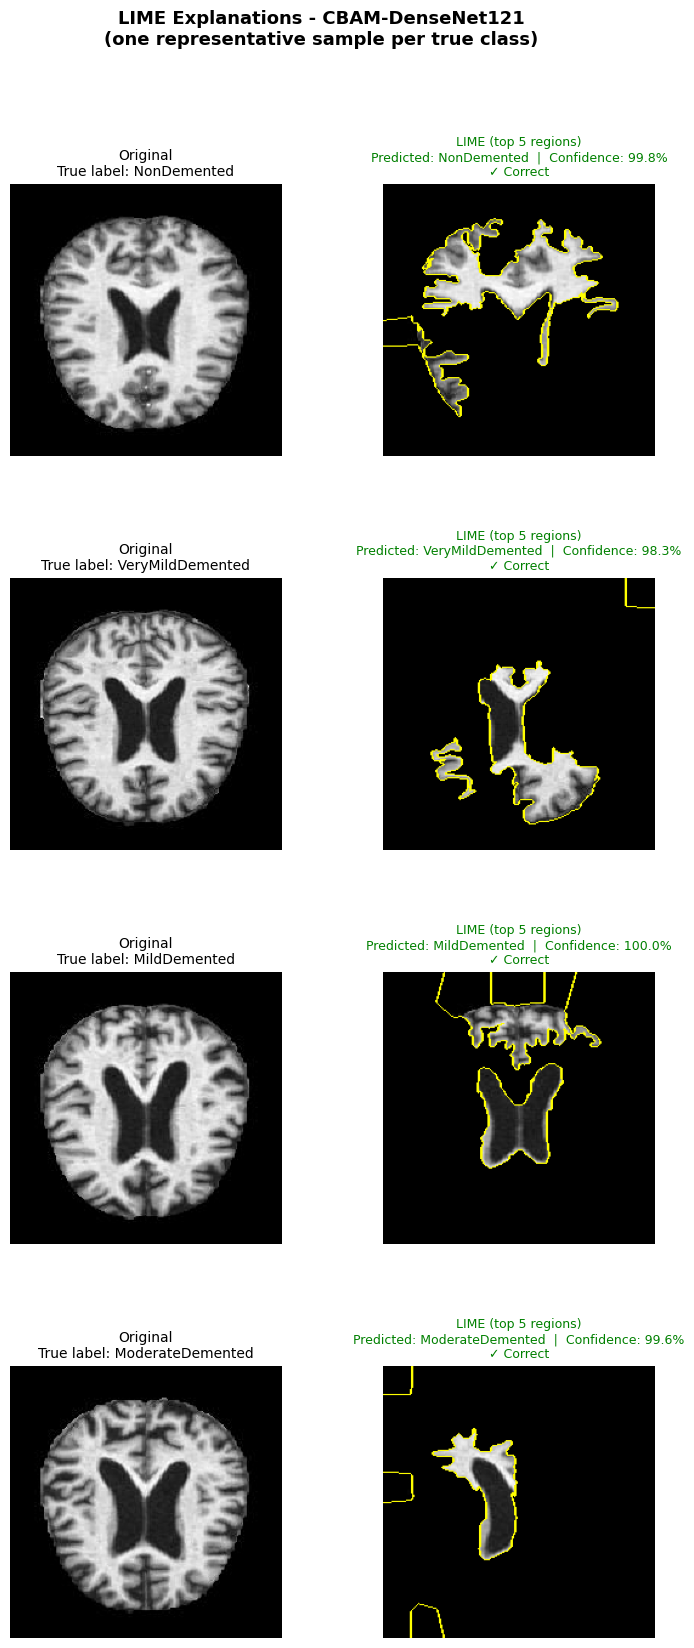

In [21]:
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
import matplotlib.pyplot as plt

def mri_segmentation_fn(image):
    return slic(image, n_segments=100, compactness=5, sigma=1, start_label=1)

def explain_with_lime(model, image, class_names, top_labels=4, num_samples=1500):
    explainer = lime_image.LimeImageExplainer()
    def predict_fn(images):
        return model.predict(images, verbose=0)
    explanation = explainer.explain_instance(
        image.astype("double"), predict_fn,
        top_labels=top_labels, hide_color=0, num_samples=num_samples,
        segmentation_fn=mri_segmentation_fn
    )
    return explanation

def get_one_sample_per_class(val_generator, class_names):
    val_generator.reset()
    found = {}
    n_classes = len(class_names)
    for images, labels in val_generator:
        for img, lbl in zip(images, labels):
            true_idx = np.argmax(lbl)
            if true_idx not in found:
                found[true_idx] = img
        if len(found) == n_classes:
            break
        if val_generator.batch_index == 0:
            break
    return found

def plot_lime_per_class(model, val_generator, class_names, num_features=5, num_samples=1500):
    plt.close('all')

    gen_class_order = [None] * len(class_names)
    for name, idx in val_generator.class_indices.items():
        gen_class_order[idx] = name
    assert gen_class_order == class_names, (
        f"MISMATCH: val_generator order is {gen_class_order} but CLASS_NAMES is {class_names}."
    )

    samples = get_one_sample_per_class(val_generator, class_names)
    n = len(samples)
    print(f"DEBUG: samples collected = {n}, class indices = {sorted(samples.keys())}")

    # Square-ish panels (4.5 wide per column, 4.5 tall per row) keep image + overlay same scale
    fig, axes = plt.subplots(n, 2, figsize=(9, 4.6 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for row, (true_idx, img) in enumerate(sorted(samples.items())):
        pred_probs = model.predict(np.expand_dims(img, 0), verbose=0)[0]
        pred_idx = np.argmax(pred_probs)
        pred_conf = pred_probs[pred_idx] * 100
        true_name = class_names[true_idx]
        pred_name = class_names[pred_idx]
        correct = (true_idx == pred_idx)

        explanation = explain_with_lime(model, img, class_names, num_samples=num_samples)
        temp, mask = explanation.get_image_and_mask(
            pred_idx, positive_only=True, num_features=num_features, hide_rest=True
        )

        axes[row, 0].imshow(img, aspect="equal")
        axes[row, 0].set_title(f"Original\nTrue label: {true_name}", fontsize=10, pad=6)
        axes[row, 0].axis("off")

        status = "✓ Correct" if correct else "✗ Misclassified"
        title_color = "green" if correct else "red"
        axes[row, 1].imshow(mark_boundaries(temp, mask), aspect="equal")
        axes[row, 1].set_title(
            f"LIME (top {num_features} regions)\n"
            f"Predicted: {pred_name}  |  Confidence: {pred_conf:.1f}%\n{status}",
            fontsize=9, color=title_color, pad=6
        )
        axes[row, 1].axis("off")

    # Small, tight gap between suptitle and row 1 (0.985 instead of 1.0/0.94 rect)
    fig.suptitle("LIME Explanations - CBAM-DenseNet121\n(one representative sample per true class)",
                 fontsize=13, fontweight="bold", y=0.995)
    plt.subplots_adjust(top=0.90, hspace=0.45, wspace=0.15)
    plt.savefig("lime_per_class.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_lime_per_class(model, val_generator, CLASS_NAMES, num_features=5)

DEBUG: samples collected = 4, class indices = [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

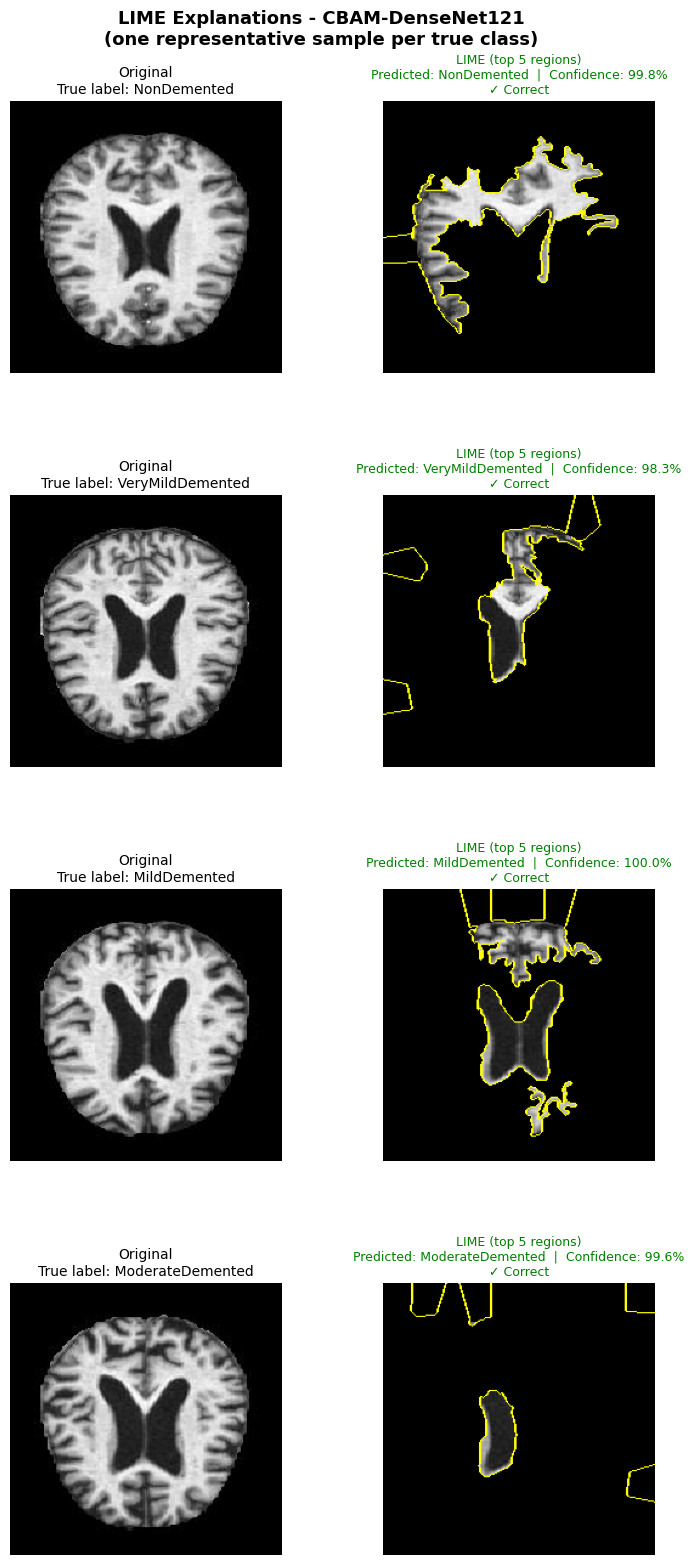

In [26]:
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
import matplotlib.pyplot as plt

def mri_segmentation_fn(image):
    return slic(image, n_segments=100, compactness=5, sigma=1, start_label=1)

def explain_with_lime(model, image, class_names, top_labels=4, num_samples=1500):
    explainer = lime_image.LimeImageExplainer()
    def predict_fn(images):
        return model.predict(images, verbose=0)
    explanation = explainer.explain_instance(
        image.astype("double"), predict_fn,
        top_labels=top_labels, hide_color=0, num_samples=num_samples,
        segmentation_fn=mri_segmentation_fn
    )
    return explanation

def get_one_sample_per_class(val_generator, class_names):
    val_generator.reset()
    found = {}
    n_classes = len(class_names)
    for images, labels in val_generator:
        for img, lbl in zip(images, labels):
            true_idx = np.argmax(lbl)
            if true_idx not in found:
                found[true_idx] = img
        if len(found) == n_classes:
            break
        if val_generator.batch_index == 0:
            break
    return found

def plot_lime_per_class(model, val_generator, class_names, num_features=5, num_samples=1500):
    plt.close('all')

    gen_class_order = [None] * len(class_names)
    for name, idx in val_generator.class_indices.items():
        gen_class_order[idx] = name
    assert gen_class_order == class_names, (
        f"MISMATCH: val_generator order is {gen_class_order} but CLASS_NAMES is {class_names}."
    )

    samples = get_one_sample_per_class(val_generator, class_names)
    n = len(samples)
    print(f"DEBUG: samples collected = {n}, class indices = {sorted(samples.keys())}")

    # Square-ish panels (4.5 wide per column, 4.5 tall per row) keep image + overlay same scale
    fig, axes = plt.subplots(n, 2, figsize=(9, 4.6 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for row, (true_idx, img) in enumerate(sorted(samples.items())):
        pred_probs = model.predict(np.expand_dims(img, 0), verbose=0)[0]
        pred_idx = np.argmax(pred_probs)
        pred_conf = pred_probs[pred_idx] * 100
        true_name = class_names[true_idx]
        pred_name = class_names[pred_idx]
        correct = (true_idx == pred_idx)

        explanation = explain_with_lime(model, img, class_names, num_samples=num_samples)
        temp, mask = explanation.get_image_and_mask(
            pred_idx, positive_only=True, num_features=num_features, hide_rest=True
        )

        axes[row, 0].imshow(img, aspect="equal")
        axes[row, 0].set_title(f"Original\nTrue label: {true_name}", fontsize=10, pad=6)
        axes[row, 0].axis("off")

        status = "✓ Correct" if correct else "✗ Misclassified"
        title_color = "green" if correct else "red"
        axes[row, 1].imshow(mark_boundaries(temp, mask), aspect="equal")
        axes[row, 1].set_title(
            f"LIME (top {num_features} regions)\n"
            f"Predicted: {pred_name}  |  Confidence: {pred_conf:.1f}%\n{status}",
            fontsize=9, color=title_color, pad=6
        )
        axes[row, 1].axis("off")

    # Small, tight gap between suptitle and row 1 (0.985 instead of 1.0/0.94 rect)
    fig.suptitle("LIME Explanations - CBAM-DenseNet121\n(one representative sample per true class)",
                 fontsize=13, fontweight="bold", y=0.95)
    plt.subplots_adjust(top=0.90, hspace=0.45, wspace=0.15)
    plt.savefig("lime_per_class.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_lime_per_class(model, val_generator, CLASS_NAMES, num_features=5)

In [27]:
def explain_with_lime(model, image, class_names, top_labels=4, num_samples=1500, random_state=42):
    explainer = lime_image.LimeImageExplainer(random_state=random_state)
    def predict_fn(images):
        return model.predict(images, verbose=0)
    explanation = explainer.explain_instance(
        image.astype("double"), predict_fn,
        top_labels=top_labels, hide_color=0, num_samples=num_samples,
        segmentation_fn=mri_segmentation_fn,
        random_seed=random_state
    )
    return explanation

DEBUG: samples collected = 4, class indices = [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

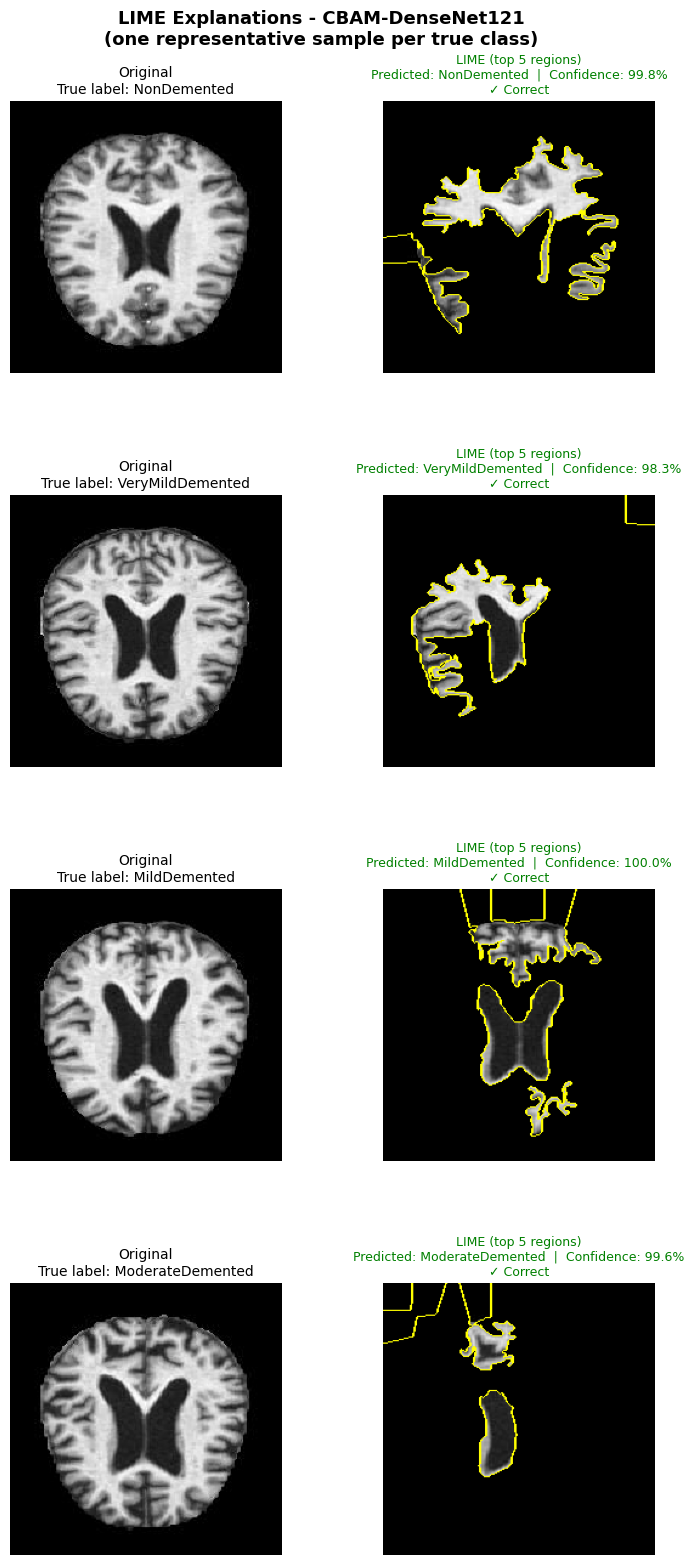

In [24]:
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
import matplotlib.pyplot as plt

# --- 1. Segmentation tuned for grayscale MRI ---
def mri_segmentation_fn(image):
    return slic(image, n_segments=100, compactness=5, sigma=1, start_label=1)

# --- 2. LIME explanation wrapper ---
def explain_with_lime(model, image, class_names, top_labels=4, num_samples=1500):
    explainer = lime_image.LimeImageExplainer()
    def predict_fn(images):
        return model.predict(images, verbose=0)
    explanation = explainer.explain_instance(
        image.astype("double"), predict_fn,
        top_labels=top_labels, hide_color=0, num_samples=num_samples,
        segmentation_fn=mri_segmentation_fn
    )
    return explanation

# --- 3. Grab one sample per class (from across the whole generator, not just batch 1) ---
def get_one_sample_per_class(val_generator, class_names):
    val_generator.reset()
    found = {}
    n_classes = len(class_names)
    for images, labels in val_generator:
        for img, lbl in zip(images, labels):
            true_idx = np.argmax(lbl)
            if true_idx not in found:
                found[true_idx] = img
        if len(found) == n_classes:
            break
        if val_generator.batch_index == 0:
            break
    return found

# --- 4. Main plotting function (final, corrected layout) ---
def plot_lime_per_class(model, val_generator, class_names, num_features=5, num_samples=1500):
    plt.close('all')  # clear any stale figures from earlier runs

    # Safety check: catches silent class_indices <-> CLASS_NAMES mismatches
    gen_class_order = [None] * len(class_names)
    for name, idx in val_generator.class_indices.items():
        gen_class_order[idx] = name
    assert gen_class_order == class_names, (
        f"MISMATCH: val_generator order is {gen_class_order} but CLASS_NAMES is {class_names}. "
        f"Fix CLASS_NAMES to match before trusting any labels below."
    )

    samples = get_one_sample_per_class(val_generator, class_names)
    n = len(samples)
    print(f"DEBUG: samples collected = {n}, class indices = {sorted(samples.keys())}")  # should be 4, [0,1,2,3]

    fig, axes = plt.subplots(n, 2, figsize=(9, 4.6 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for row, (true_idx, img) in enumerate(sorted(samples.items())):
        pred_probs = model.predict(np.expand_dims(img, 0), verbose=0)[0]
        pred_idx = np.argmax(pred_probs)
        pred_conf = pred_probs[pred_idx] * 100
        true_name = class_names[true_idx]
        pred_name = class_names[pred_idx]
        correct = (true_idx == pred_idx)

        explanation = explain_with_lime(model, img, class_names, num_samples=num_samples)
        temp, mask = explanation.get_image_and_mask(
            pred_idx, positive_only=True, num_features=num_features, hide_rest=True
        )

        axes[row, 0].imshow(img, aspect="equal")
        axes[row, 0].set_title(f"Original\nTrue label: {true_name}", fontsize=10, pad=6)
        axes[row, 0].axis("off")

        status = "✓ Correct" if correct else "✗ Misclassified"
        title_color = "green" if correct else "red"
        axes[row, 1].imshow(mark_boundaries(temp, mask), aspect="equal")
        axes[row, 1].set_title(
            f"LIME (top {num_features} regions)\n"
            f"Predicted: {pred_name}  |  Confidence: {pred_conf:.1f}%\n{status}",
            fontsize=9, color=title_color, pad=6
        )
        axes[row, 1].axis("off")

    fig.suptitle("LIME Explanations - CBAM-DenseNet121\n(one representative sample per true class)",
                 fontsize=13, fontweight="bold", y=0.95)
    plt.subplots_adjust(top=0.90, hspace=0.45, wspace=0.15)
    plt.savefig("lime_per_class.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# --- Run it ---
plot_lime_per_class(model, val_generator, CLASS_NAMES, num_features=5)

#rk shap

PartitionExplainer explainer: 5it [00:16,  8.45s/it]               


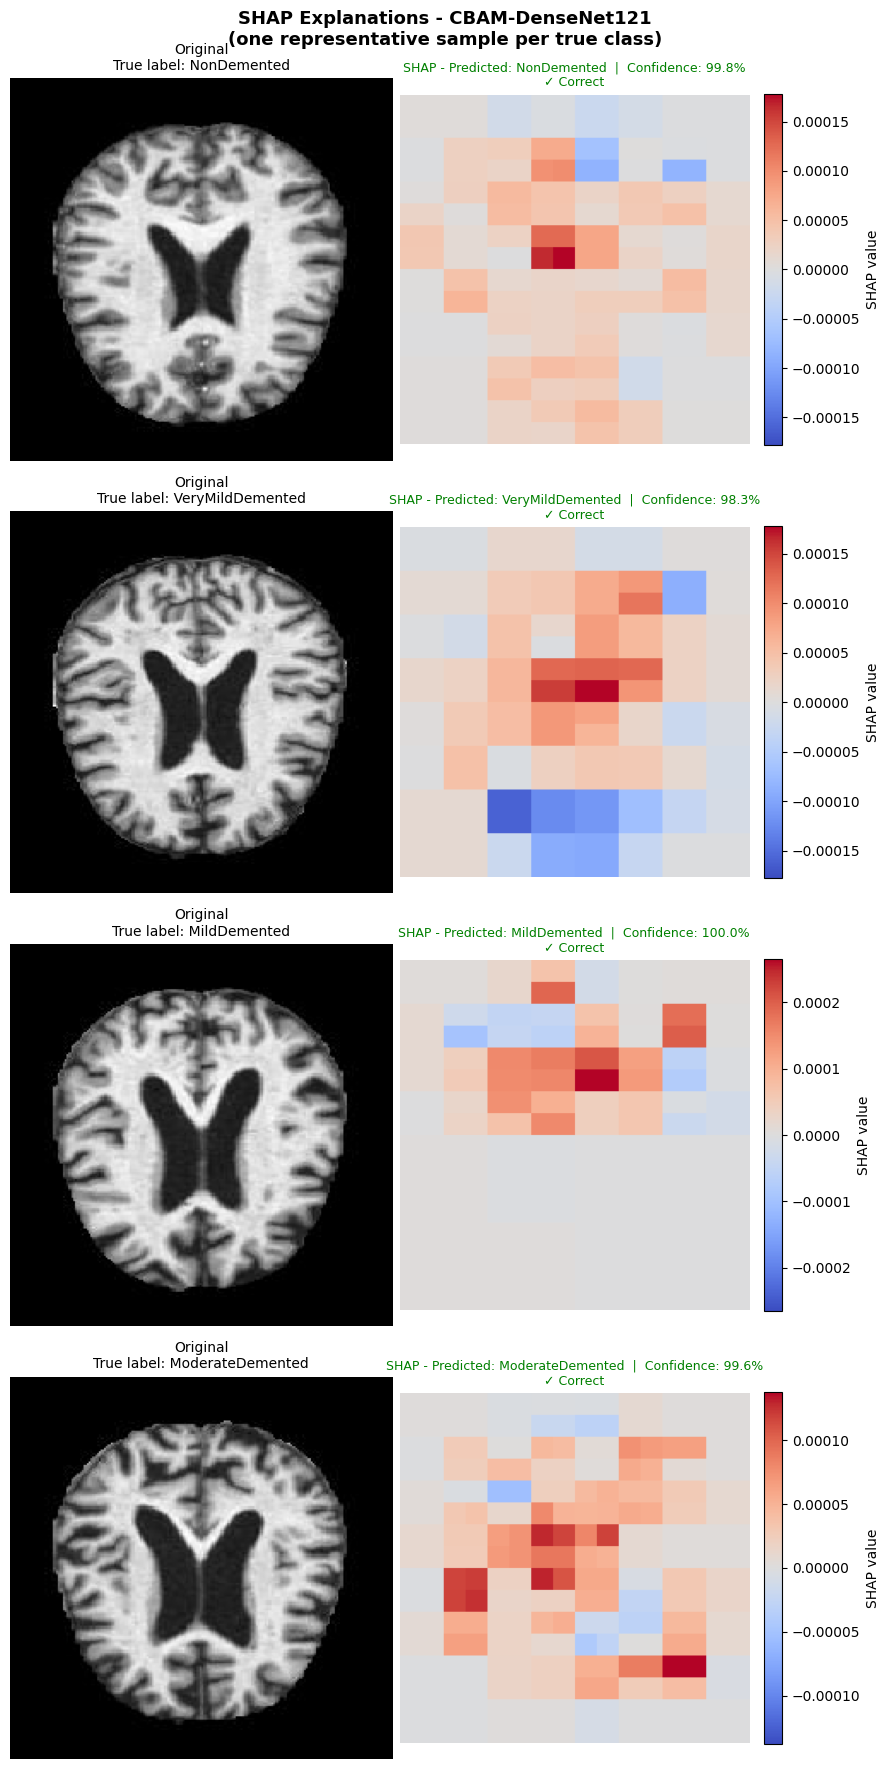

In [16]:
import shap
import numpy as np
import matplotlib.pyplot as plt

def plot_shap_per_class(model, val_generator, class_names, max_evals=500):
    # Reuse the same per-class sampler from the LIME fix
    samples = get_one_sample_per_class(val_generator, class_names)
    n = len(samples)

    test_images = np.array([samples[idx] for idx in sorted(samples.keys())])
    true_indices = sorted(samples.keys())

    def predict_fn(imgs):
        return model.predict(imgs, verbose=0)

    masker = shap.maskers.Image("blur(32,32)", test_images[0].shape)
    explainer = shap.Explainer(predict_fn, masker, output_names=class_names)

    shap_values = explainer(
        test_images,
        max_evals=max_evals,
        batch_size=32,
        outputs=shap.Explanation.argsort.flip[:1]
    )

    fig, axes = plt.subplots(n, 2, figsize=(9, 4.5 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for row in range(n):
        true_idx = true_indices[row]
        img = test_images[row]
        pred_probs = model.predict(np.expand_dims(img, 0), verbose=0)[0]
        pred_idx = np.argmax(pred_probs)
        pred_conf = pred_probs[pred_idx] * 100

        true_name = class_names[true_idx]
        pred_name = class_names[pred_idx]
        correct = (true_idx == pred_idx)
        status = "✓ Correct" if correct else "✗ Misclassified"
        title_color = "green" if correct else "red"

        # shap_values.values shape: (n_samples, H, W, C, n_outputs)
        sv = shap_values.values[row][..., 0]      # first (top) output explained
        sv_2d = sv.sum(axis=-1)                   # collapse RGB channels to one heatmap

        axes[row, 0].imshow(img)
        axes[row, 0].set_title(f"Original\nTrue label: {true_name}", fontsize=10)
        axes[row, 0].axis("off")

        vmax = np.abs(sv_2d).max()
        im = axes[row, 1].imshow(sv_2d, cmap="coolwarm", vmin=-vmax, vmax=vmax)
        axes[row, 1].set_title(
            f"SHAP - Predicted: {pred_name}  |  Confidence: {pred_conf:.1f}%\n{status}",
            fontsize=9, color=title_color
        )
        axes[row, 1].axis("off")
        plt.colorbar(im, ax=axes[row, 1], fraction=0.046, pad=0.04, label="SHAP value")

    fig.suptitle("SHAP Explanations - CBAM-DenseNet121\n(one representative sample per true class)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("shap_per_class.png", dpi=300, bbox_inches="tight")
    plt.show()

    return shap_values

shap_values = plot_shap_per_class(model, val_generator, CLASS_NAMES, max_evals=500)

PartitionExplainer explainer: 5it [00:16,  8.02s/it]               


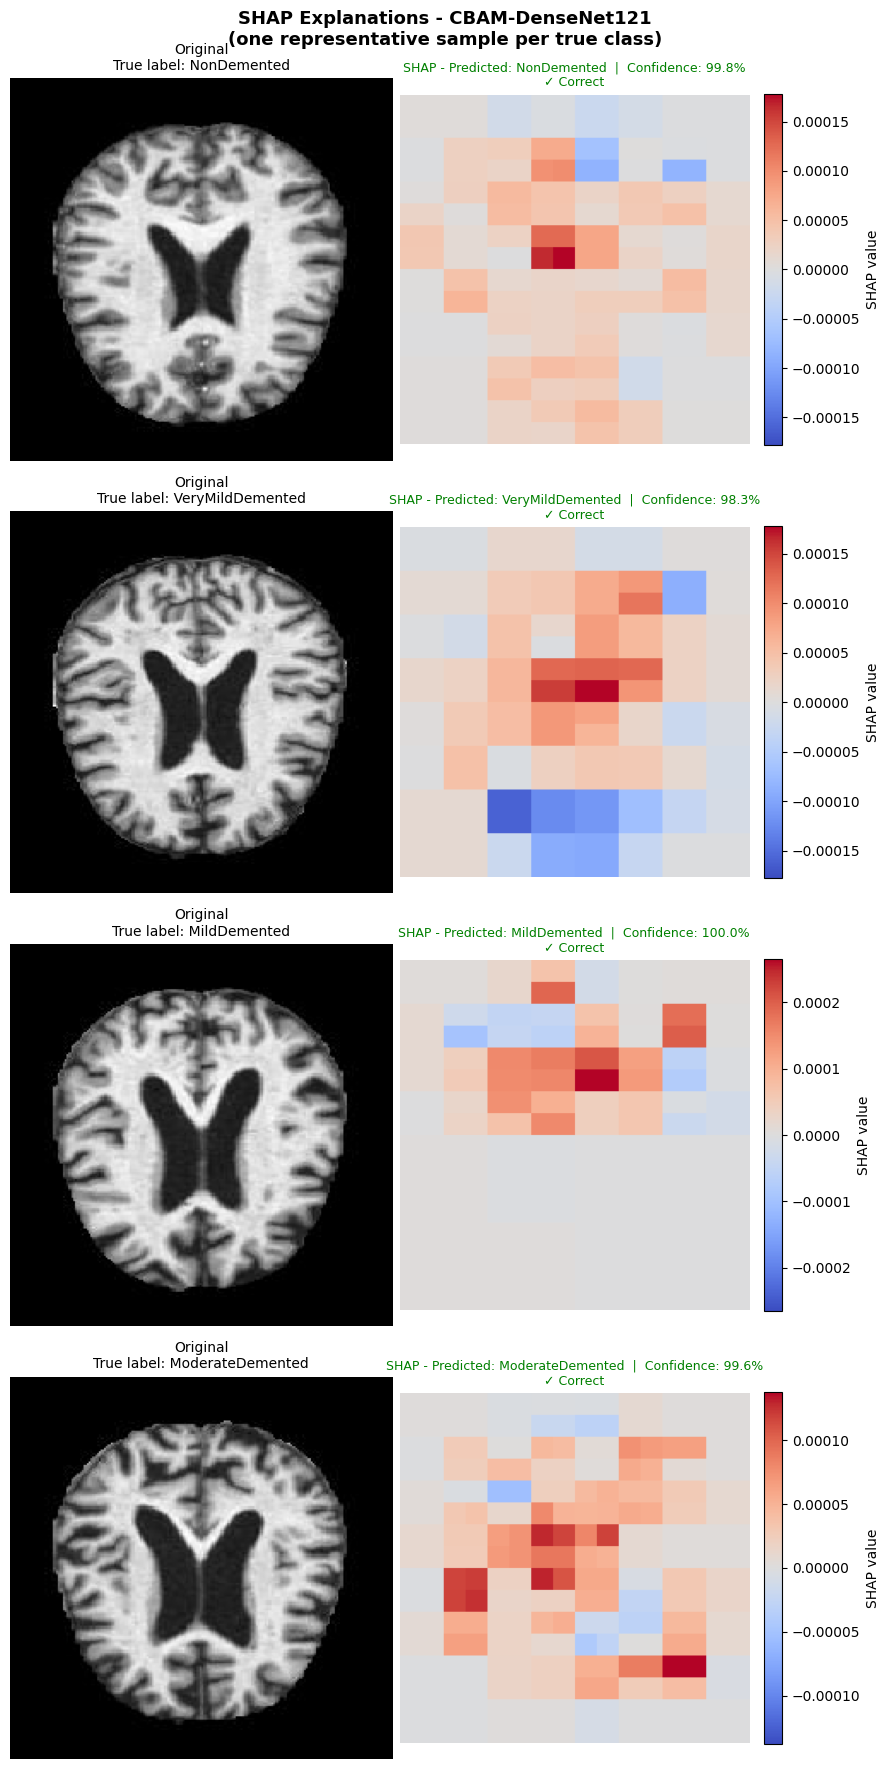

  0%|          | 0/998 [00:00<?, ?it/s]

PartitionExplainer explainer:  25%|██▌       | 1/4 [00:00<?, ?it/s]

  0%|          | 0/998 [00:00<?, ?it/s]

PartitionExplainer explainer:  75%|███████▌  | 3/4 [00:27<00:03,  3.73s/it]

  0%|          | 0/998 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 4/4 [00:34<00:00,  5.32s/it]

  0%|          | 0/998 [00:00<?, ?it/s]

PartitionExplainer explainer: 5it [00:42, 10.52s/it]                       


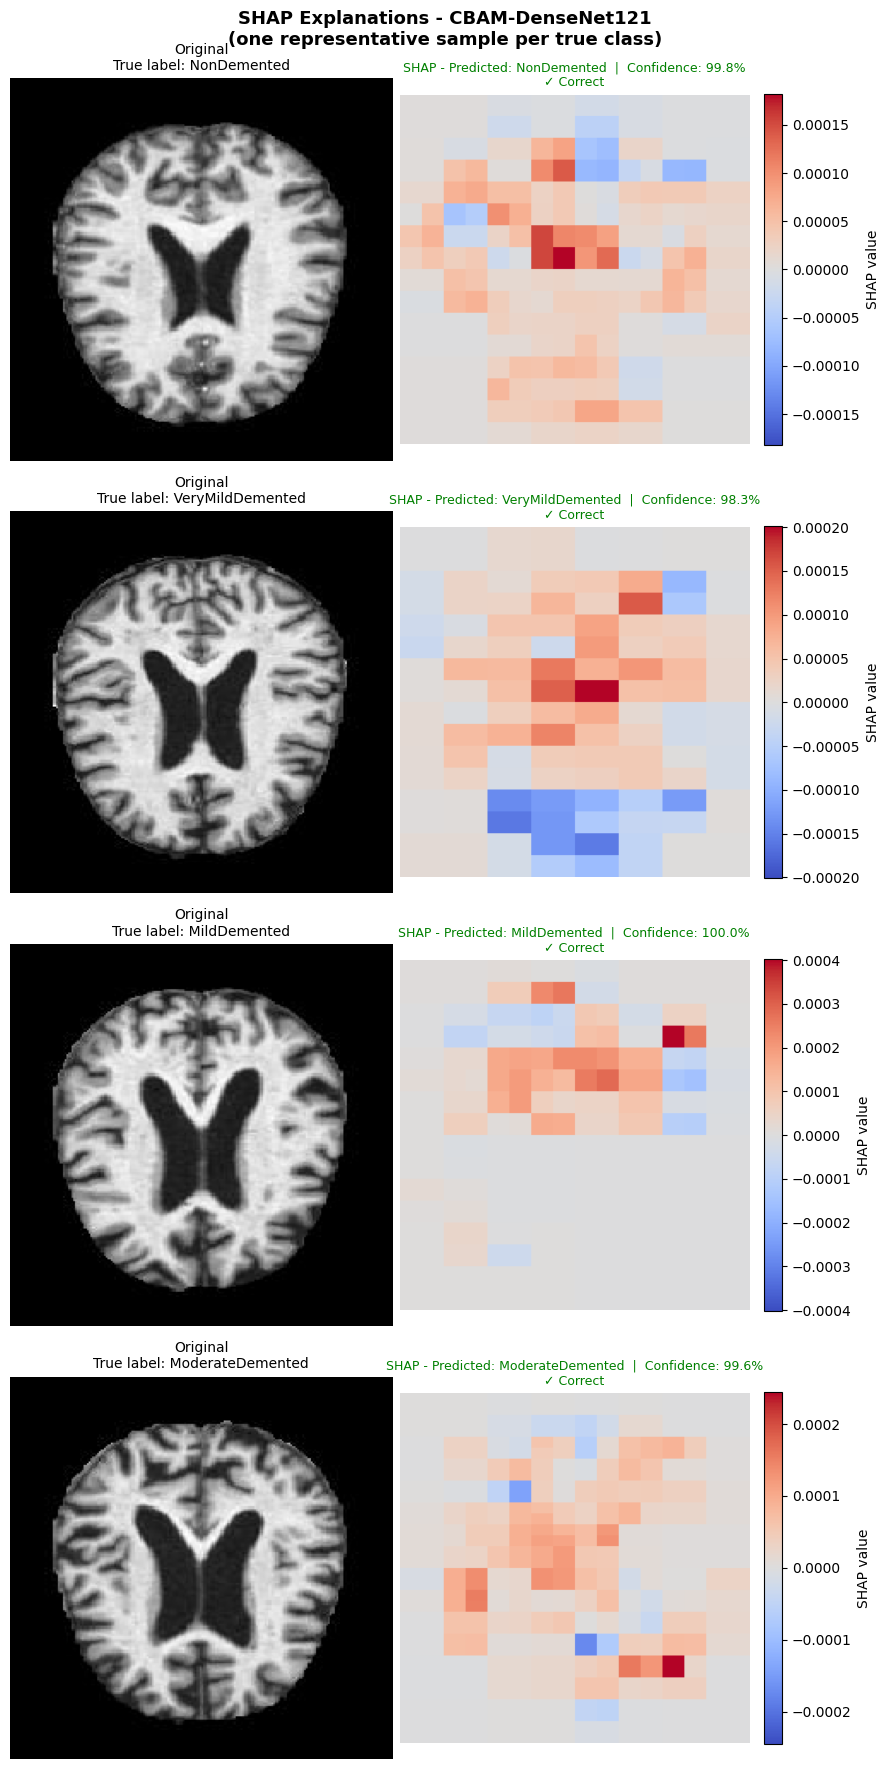

Max pixel-region difference between max_evals=500 vs 1000: 0.000065
Mean difference: 0.000009


In [18]:
# Run twice with different max_evals and compare — if results are stable, you can
# report the lower (faster) max_evals with confidence
shap_values_500 = plot_shap_per_class(model, val_generator, CLASS_NAMES, max_evals=500)
shap_values_1000 = plot_shap_per_class(model, val_generator, CLASS_NAMES, max_evals=1000)

# Compare the two heatmaps for the same image (e.g. row 0)
diff = np.abs(shap_values_500.values[0][...,0].sum(axis=-1) -
               shap_values_1000.values[0][...,0].sum(axis=-1))
print(f"Max pixel-region difference between max_evals=500 vs 1000: {diff.max():.6f}")
print(f"Mean difference: {diff.mean():.6f}")

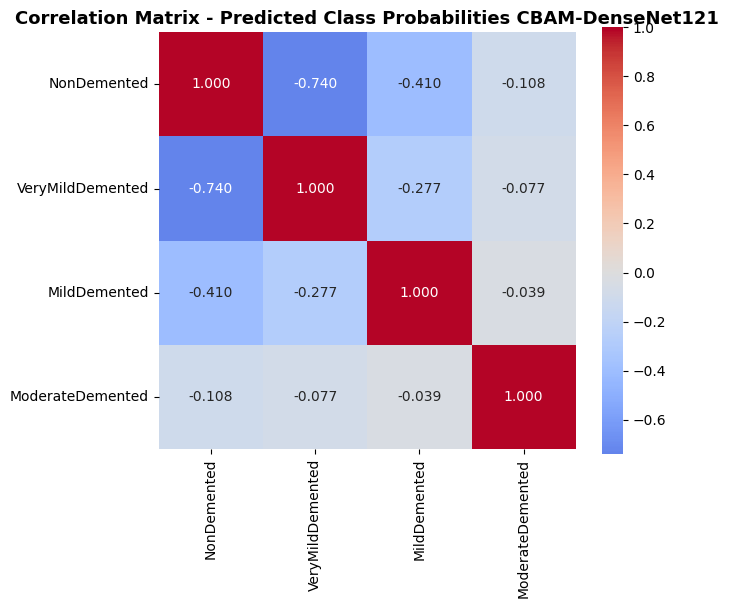

In [29]:
def plot_probability_correlation(y_pred_probs, class_names):
    df_probs = pd.DataFrame(y_pred_probs, columns=class_names)
    corr = df_probs.corr()

    plt.figure(figsize=(7, 6))
    sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0,
                xticklabels=class_names, yticklabels=class_names, square=True)
    plt.title("Correlation Matrix - Predicted Class Probabilities CBAM-DenseNet121", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("probability_correlation_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_probability_correlation(y_pred_probs, CLASS_NAMES)

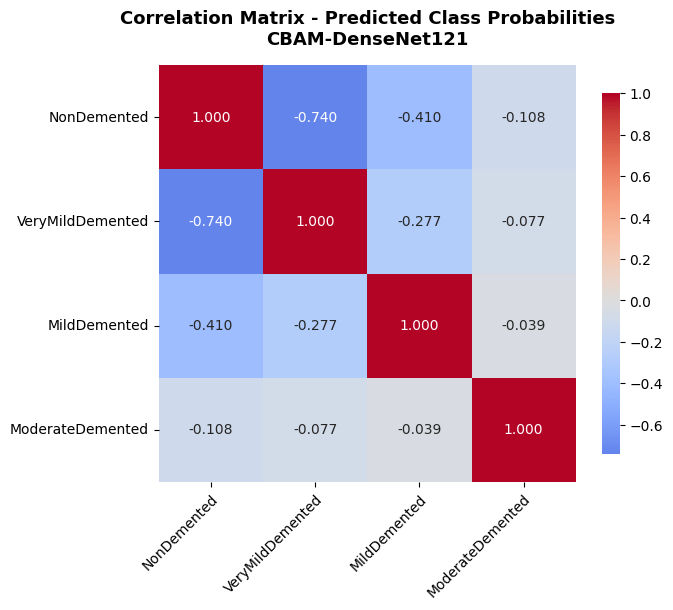

In [30]:
def plot_probability_correlation(y_pred_probs, class_names):
    df_probs = pd.DataFrame(y_pred_probs, columns=class_names)
    corr = df_probs.corr()

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0,
                xticklabels=class_names, yticklabels=class_names, square=True,
                ax=ax, cbar_kws={"shrink": 0.85})

    ax.set_title("Correlation Matrix - Predicted Class Probabilities\nCBAM-DenseNet121",
                  fontsize=13, fontweight="bold", pad=15)

    # Fix label clipping: rotate and align properly
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    plt.tight_layout()
    plt.savefig("probability_correlation_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_probability_correlation(y_pred_probs, CLASS_NAMES)

In [ ]:
def plot_probability_correlation(y_pred_probs, class_names):
    df_probs = pd.DataFrame(y_pred_probs, columns=class_names)
    corr = df_probs.corr()

    plt.figure(figsize=(7, 6))
    sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0,
                xticklabels=class_names, yticklabels=class_names, square=True)
    plt.title("Correlation Matrix - Predicted Class Probabilities", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("probability_correlation_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_probability_correlation(y_pred_probs, CLASS_NAMES)

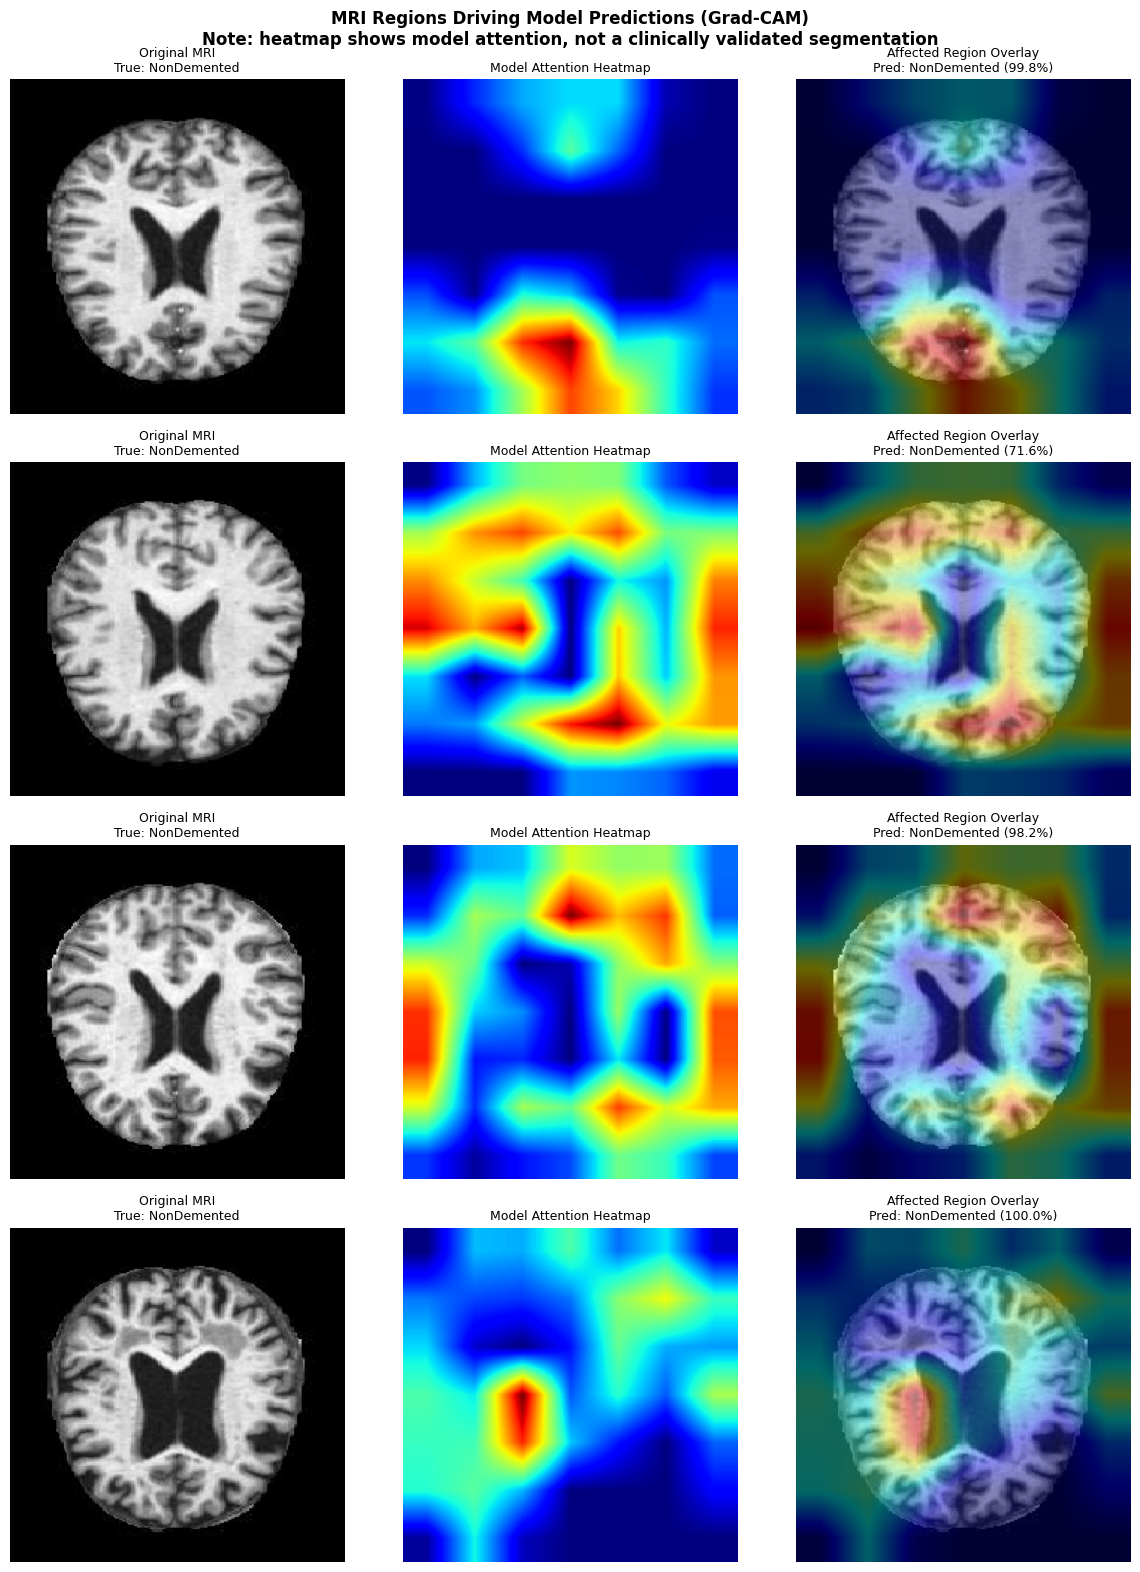

In [35]:
# ============================================================
# Imports (run this first)
# ============================================================
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


# ============================================================
# Grad-CAM heatmap generator
# ============================================================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


# ============================================================
# Overlay heatmap on original MRI
# ============================================================
def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    img_uint8 = np.uint8(255 * img) if img.max() <= 1.0 else np.uint8(img)

    overlay = cv2.addWeighted(img_uint8, 1 - alpha, heatmap_color, alpha, 0)
    return overlay


# ============================================================
# Main plotting function
# ============================================================
def plot_affected_region_mri(model, val_generator, class_names, last_conv_layer_name, n_samples=4):
    val_generator.reset()
    images, labels = next(val_generator)
    n_samples = min(n_samples, len(images))
    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, 3)

    for i in range(n_samples):
        img = images[i]
        img_array = np.expand_dims(img, axis=0)
        true_idx = np.argmax(labels[i])
        preds = model.predict(img_array, verbose=0)[0]
        pred_idx = np.argmax(preds)
        conf = preds[pred_idx]

        heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=pred_idx)
        heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
        overlay = overlay_gradcam(img, heatmap_resized)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Original MRI\nTrue: {class_names[true_idx]}", fontsize=9)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(heatmap_resized, cmap="jet")
        axes[i, 1].set_title("Model Attention Heatmap", fontsize=9)
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title(f"Affected Region Overlay\nPred: {class_names[pred_idx]} ({conf*100:.1f}%)", fontsize=9)
        axes[i, 2].axis("off")

    fig.suptitle("MRI Regions Driving Model Predictions (Grad-CAM)\n"
                  "Note: heatmap shows model attention, not a clinically validated segmentation",
                  fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("mri_affected_regions.png", dpi=300, bbox_inches="tight")
    plt.show()


# ============================================================
# Run
# ============================================================
plot_affected_region_mri(model, val_generator, CLASS_NAMES, last_conv_layer_name="conv5_block16_concat")

In [36]:
def get_one_sample_per_class(val_generator, class_names):
    """Pulls exactly one image per class, regardless of batch order/shuffle."""
    val_generator.reset()
    found = {}
    images_all, labels_all = [], []

    # Pull batches until we have at least one sample of every class
    while len(found) < len(class_names):
        images, labels = next(val_generator)
        for img, lbl in zip(images, labels):
            cls_idx = np.argmax(lbl)
            if cls_idx not in found:
                found[cls_idx] = (img, lbl)
        # safety: avoid infinite loop if a class is rare/absent in this generator
        if val_generator.batch_index == 0:
            break

    # Order them by class_names order
    images_ordered = [found[i][0] for i in range(len(class_names)) if i in found]
    labels_ordered = [found[i][1] for i in range(len(class_names)) if i in found]
    return np.array(images_ordered), np.array(labels_ordered)

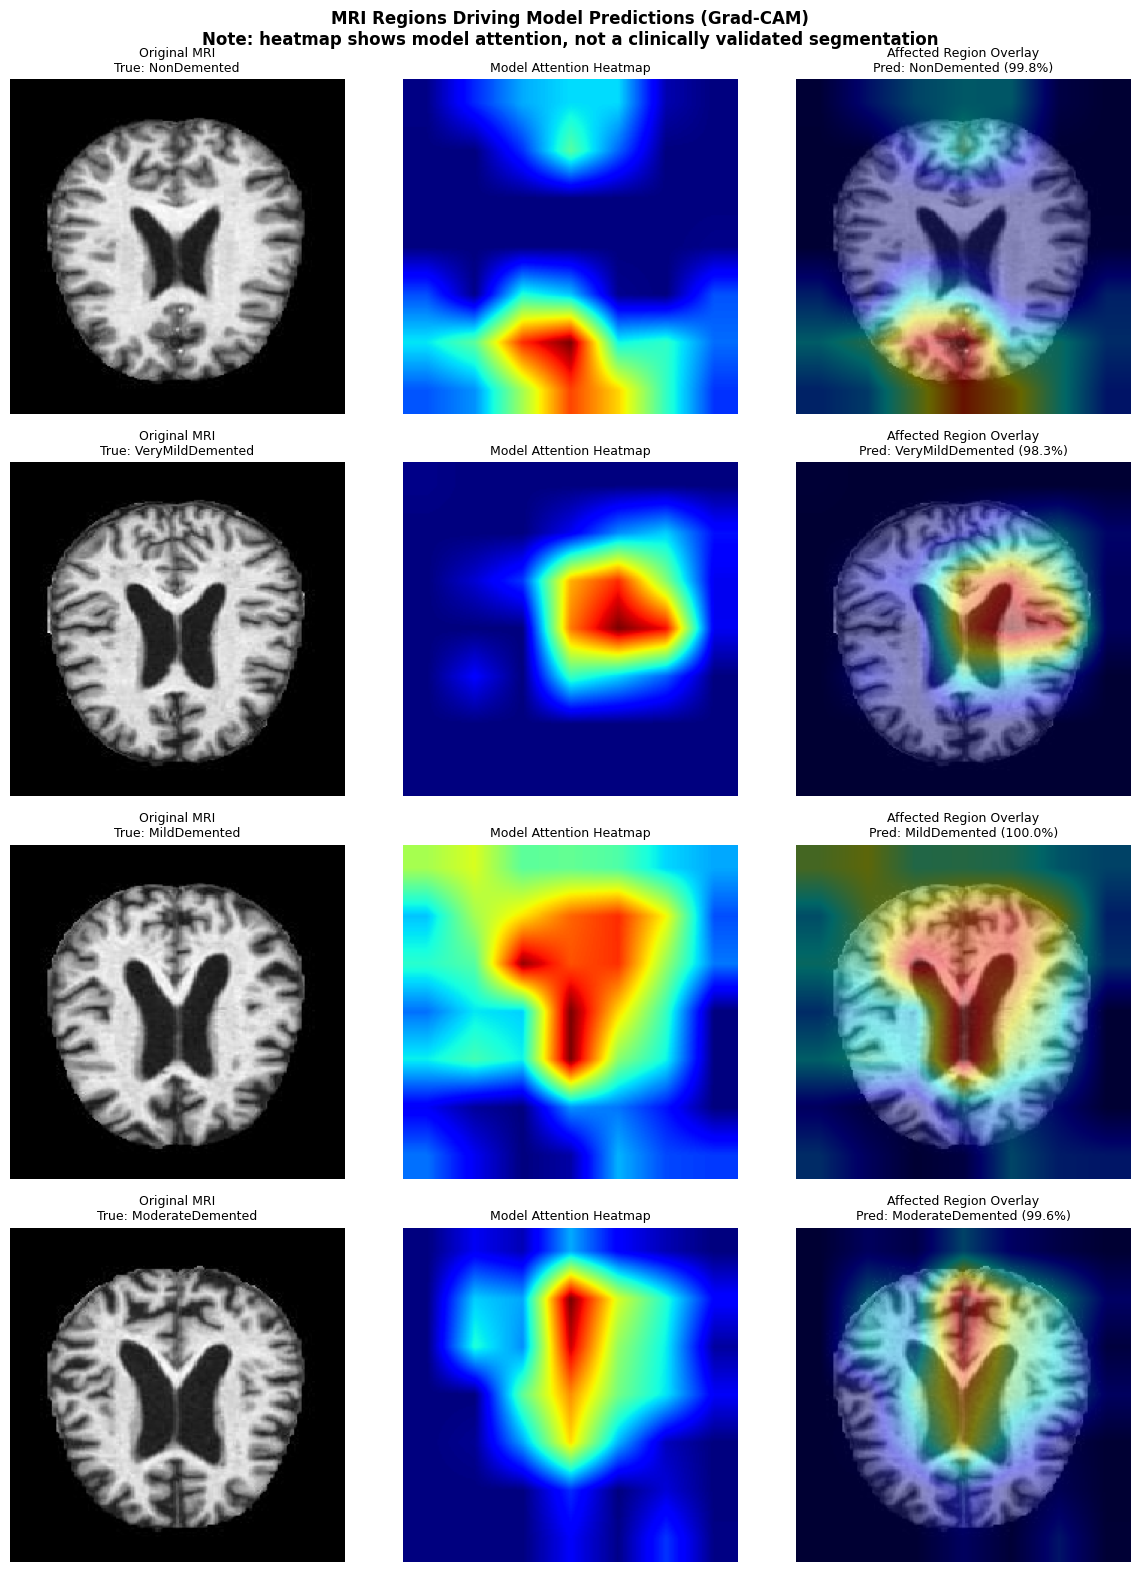

In [37]:
def plot_affected_region_mri(model, val_generator, class_names, last_conv_layer_name, n_samples=None):
    images, labels = get_one_sample_per_class(val_generator, class_names)
    n_samples = len(images) if n_samples is None else min(n_samples, len(images))

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, 3)

    for i in range(n_samples):
        img = images[i]
        img_array = np.expand_dims(img, axis=0)
        true_idx = np.argmax(labels[i])
        preds = model.predict(img_array, verbose=0)[0]
        pred_idx = np.argmax(preds)
        conf = preds[pred_idx]

        heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=pred_idx)
        heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
        overlay = overlay_gradcam(img, heatmap_resized)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Original MRI\nTrue: {class_names[true_idx]}", fontsize=9)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(heatmap_resized, cmap="jet")
        axes[i, 1].set_title("Model Attention Heatmap", fontsize=9)
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title(f"Affected Region Overlay\nPred: {class_names[pred_idx]} ({conf*100:.1f}%)", fontsize=9)
        axes[i, 2].axis("off")

    fig.suptitle("MRI Regions Driving Model Predictions (Grad-CAM)\n"
                  "Note: heatmap shows model attention, not a clinically validated segmentation",
                  fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("mri_affected_regions.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_affected_region_mri(model, val_generator, CLASS_NAMES, last_conv_layer_name="conv5_block16_concat")

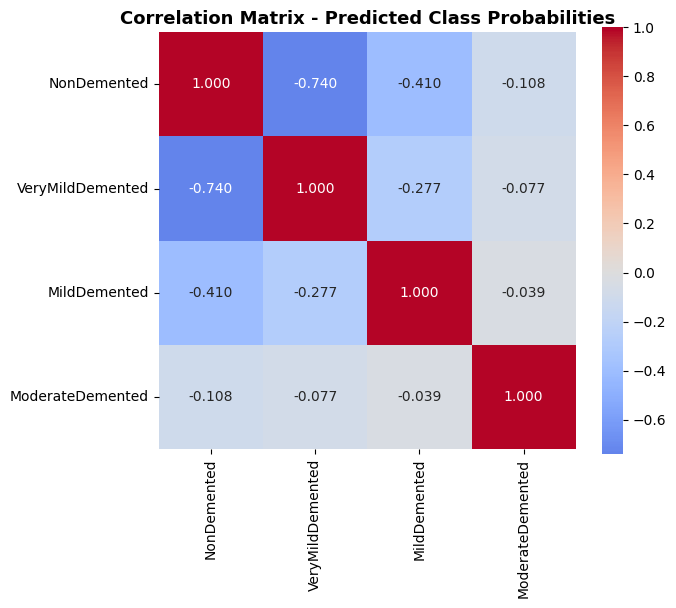

In [39]:
def plot_probability_correlation(y_pred_probs, class_names):
    df_probs = pd.DataFrame(y_pred_probs, columns=class_names)
    corr = df_probs.corr()

    plt.figure(figsize=(7, 6))
    sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0,
                xticklabels=class_names, yticklabels=class_names, square=True)
    plt.title("Correlation Matrix - Predicted Class Probabilities", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("probability_correlation_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_probability_correlation(y_pred_probs, CLASS_NAMES)